In [1]:
!rm *.svg

rm: cannot remove '*.svg': No such file or directory


# Figure 1b

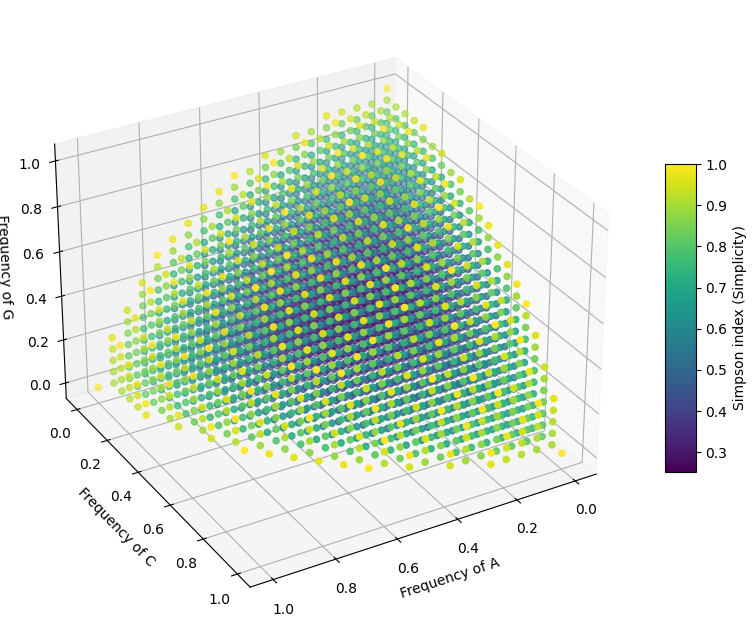

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.0, 1.0, 20)
y = np.linspace(0.0, 1.0, 20)
z = np.linspace(0.0, 1.0, 20)
X, Y, Z = np.meshgrid(x, y, z)

W = X**2 + Y**2 + Z**2 + (1 - X - Y - Z)**2
mask = W <= 1.0
X_f, Y_f, Z_f, W_f = X[mask], Y[mask], Z[mask], W[mask]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_f, Y_f, Z_f, c=W_f, cmap='viridis')

ax.set_xlabel('Frequency of A')
ax.set_ylabel('Frequency of C')
ax.set_zlabel('Frequency of G')

cbar = fig.colorbar(scatter, shrink=0.5, aspect=10)
cbar.set_label('Simpson index (Simplicity)')

ax.view_init(elev=30, azim=60)
plt.savefig('SimpsonIndex.svg', dpi=350)
plt.show()

# Figure 1c

0.03502904


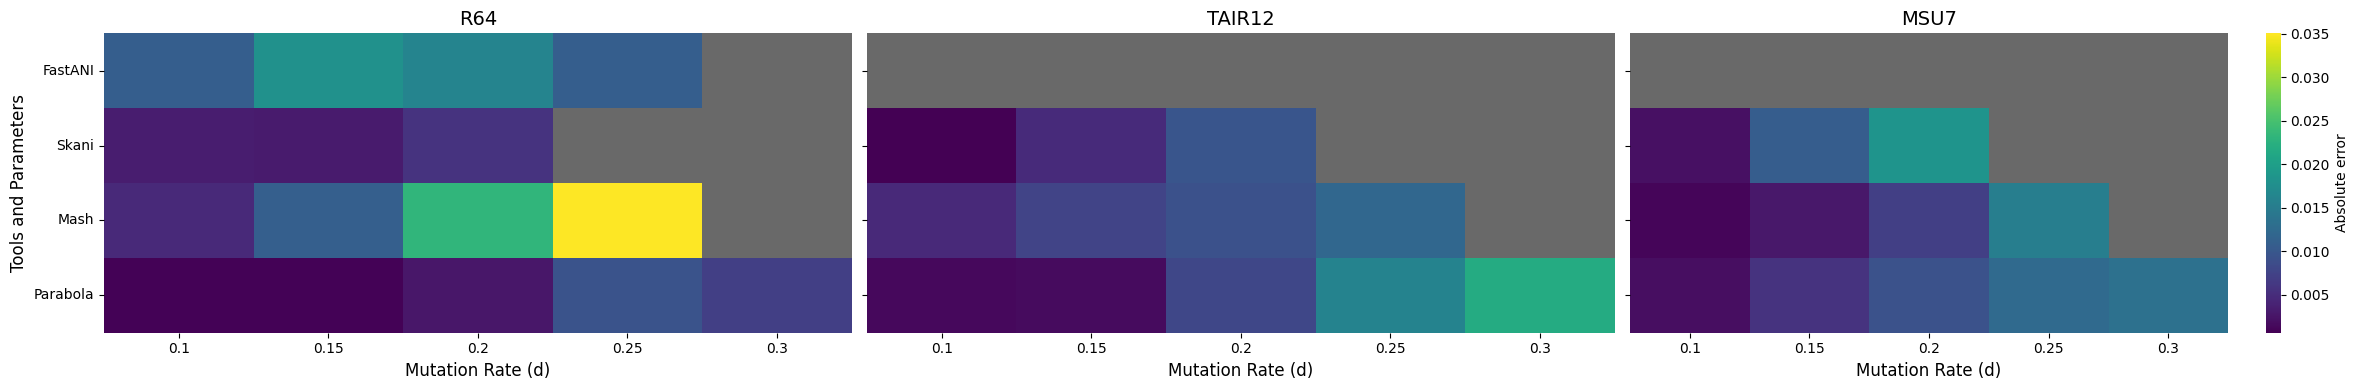

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('Parabola-SupplTable1.csv')
df = df[df['Mode'] == 'SNP_INDEL']

df['k'] = pd.to_numeric(df['k'], errors='coerce')
if 'C_rate' in df.columns:
    df['C_rate'] = pd.to_numeric(df['C_rate'], errors='coerce')

mask = pd.Series(False, index=df.index)
tool_lower = df['Tool'].str.lower()

mask |= (tool_lower == 'fastani')

mask |= (tool_lower == 'skani')
mask |= (tool_lower == 'mash') # & (df['k'] == 21))
mask |= (tool_lower == 'parabola') # & (df['k'] == 21))

df = df[mask].copy()

err_cols = [c for c in df.columns if 'ERR_d=' in c]
param_cols = ['Tool', 'k', 'C_rate', 'Genome']
existing_param_cols = [c for c in param_cols if c in df.columns]

df_err = df.melt(id_vars=existing_param_cols, value_vars=err_cols, var_name='d_col', value_name='Err')
df_err['d'] = df_err['d_col'].apply(lambda x: float(re.search(r'[^d=]+', x.split('=')[-1]).group()))
df_err = df_err[df_err['d'] < 0.40]

def make_label(row):
    tool = str(row.get('Tool', 'Unknown')).strip()
    tool_lower = tool.lower()

    if tool_lower == 'fastani':
        return 'FastANI'
    elif tool_lower == 'mash':
        return 'Mash'
    elif tool_lower == 'parabola':
        return 'Parabola'

    k_val = row.get('k', pd.NA)
    k_str = f"k={int(k_val)}" if pd.notna(k_val) else ""

    params = [p for p in [k_str] if p]

    if params:
        return f"{tool} ({', '.join(params)})"
    return tool

df_err['Tool_Label'] = df_err.apply(make_label, axis=1)

df_filtered = df_err.copy()

def get_sort_key(label):
    label_lower = label.lower()

    if 'fastani' in label_lower: order = 1
    elif 'skani' in label_lower: order = 2
    elif 'mash' in label_lower: order = 3
    elif 'parabola' in label_lower: order = 4
    else: order = 5

    match = re.search(r'k=(\d+)', label)
    k_val = int(match.group(1)) if match else 0

    return (order, k_val, label_lower)

genomes = df_filtered['Genome'].unique()
num_genomes = len(genomes)

unique_labels = df_filtered['Tool_Label'].unique()

global_sorted_labels = sorted(unique_labels, key=get_sort_key)

fig_height = max(4, len(global_sorted_labels) * 0.5)
fig_width = max(8, 8 * num_genomes)

fig, axes = plt.subplots(1, num_genomes, figsize=(fig_width, fig_height), sharey=True)

if num_genomes == 1:
    axes = [axes]

agg_err = df_filtered.groupby(['Genome', 'Tool_Label', 'd'])['Err'].mean()
global_vmin = agg_err.min()
global_vmax = agg_err.max()
print(global_vmax)

for i, genome in enumerate(genomes):
    df_g = df_filtered[(df_filtered['Genome'] == genome)]

    pivot_df = df_g.pivot_table(index='Tool_Label', columns='d', values='Err', aggfunc='mean')

    pivot_df = pivot_df.reindex(global_sorted_labels)

    ax = axes[i]
    ax.set_facecolor('dimgrey')

    show_cbar = (i == num_genomes - 1)

    sns.heatmap(pivot_df, annot=False, fmt=".3f", cmap="viridis", ax=ax,
                vmin=global_vmin, vmax=global_vmax,
                cbar=show_cbar, cbar_kws={'label': 'Absolute error'} if show_cbar else None)

    ax.set_title(f'{genome}', fontsize=14)
    ax.set_xlabel('Mutation Rate (d)', fontsize=12)

    if i == 0:
        ax.set_ylabel('Tools and Parameters', fontsize=12)
    else:
        ax.set_ylabel('')

    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("err_heatmap.svg")
plt.show()
plt.close()

# Figure 1d

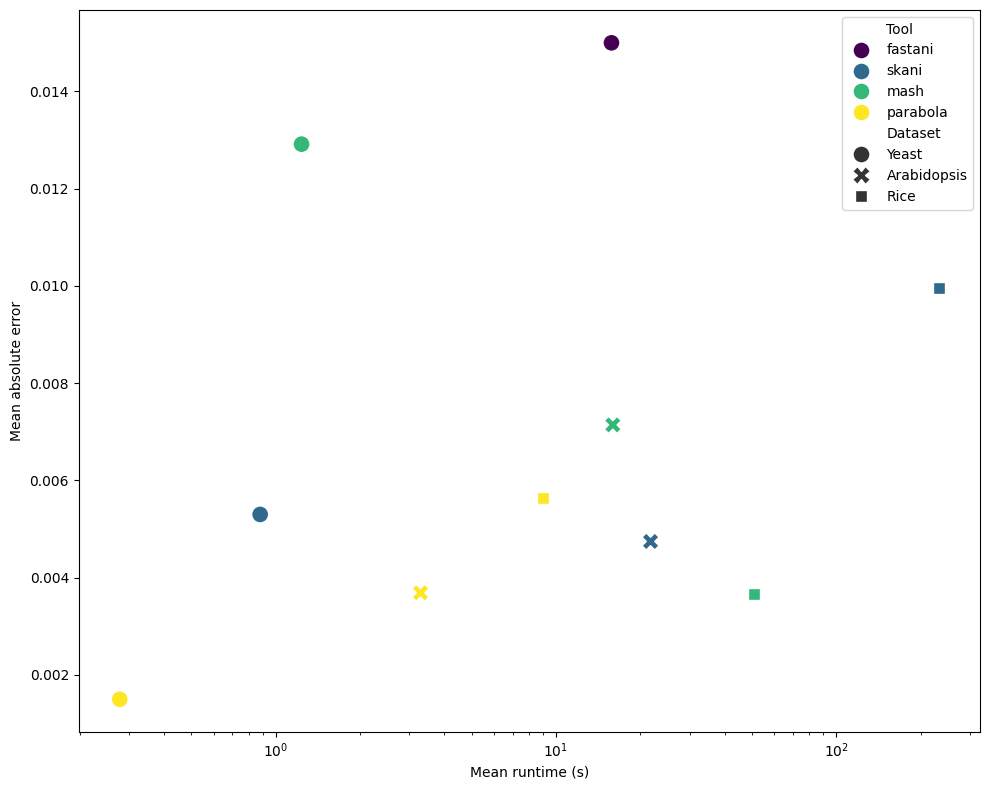

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

palette_raw = {
    'fastani': '#440154',
    'skani': '#31688e',
    'mash': '#35b779',
    'parabola': '#fde725',
}

df = pd.read_csv('Parabola-SupplTable1.csv')
df = df[df['Mode'] == 'SNP_INDEL']

df['Tool'] = df['Tool'].str.lower()
tool_order = list(palette_raw.keys())

time_cols = [c for c in df.columns if 'Time_N=' in c]

err_cols = [c for c in df.columns if 'ERR_d=' in c]
err_cols_filtered = [c for c in err_cols if float(c.split('=')[1]) <= 0.20]

df['Dataset'] = df['Genome'].map({'R64': 'Yeast', 'TAIR12': 'Arabidopsis', 'MSU7': "Rice"})

df['Time'] = df[time_cols].mean(axis=1)
df['Err_filtered'] = df[err_cols_filtered].mean(axis=1)

best_df_filtered = df.groupby(['Tool', 'Dataset'])[['Time', 'Err_filtered']].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.scatterplot(data=best_df_filtered, x='Time', y='Err_filtered', hue='Tool', style='Dataset', s=150,
                palette=palette_raw, hue_order=tool_order)

plt.xlabel('Mean runtime (s)')
plt.ylabel('Mean absolute error')
plt.xscale('log')
plt.tight_layout()
plt.savefig("tradeoff_best_d020.svg")
plt.show()
plt.close()

## Figure 2ab

/tmp/ipykernel_5214/4283922023.py:14: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df, x='Taxon', y='nRF', hue='Tool', palette=colors,


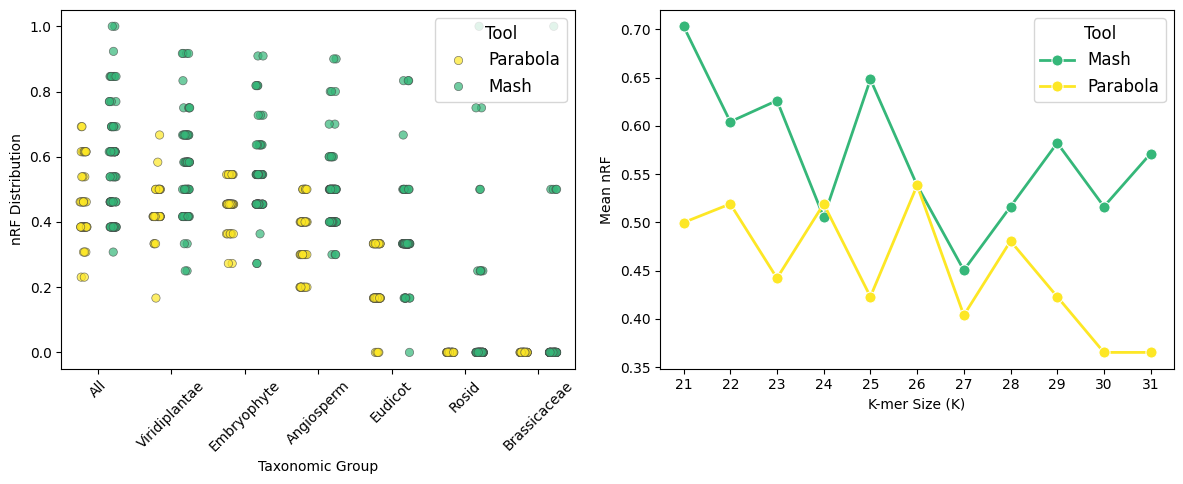

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Parabola-SupplTable3.csv')

colors = {'Parabola': '#fde725', 'Mash': '#35b779'}
taxon_order = ['All', 'Viridiplantae', 'Embryophyte', 'Angiosperm', 'Eudicot', 'Rosid', 'Brassicaceae']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.rcParams.update({'font.size': 12})

ax = axes[0]
sns.stripplot(data=df, x='Taxon', y='nRF', hue='Tool', palette=colors,
              order=taxon_order, ax=ax, dodge=True, jitter=True, alpha=0.7, size=6, linewidth=0.5, edgecolor='gray')
ax.set_ylabel('nRF Distribution')
ax.set_xlabel('Taxonomic Group')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
all_df = df[df['Taxon'] == 'All']
avg_k_nrf = all_df.groupby(['K', 'Tool'])['nRF'].mean().reset_index()
sns.lineplot(data=avg_k_nrf, x='K', y='nRF', hue='Tool', palette=colors,
             marker='o', linewidth=2, markersize=8, ax=ax)
ax.set_ylabel('Mean nRF')
ax.set_xlabel('K-mer Size (K)')
ax.set_xticks(sorted(df['K'].dropna().unique()))

plt.tight_layout()
plt.savefig('parabola_nRF.svg')
plt.show()
plt.close()

# Extended data figure 1

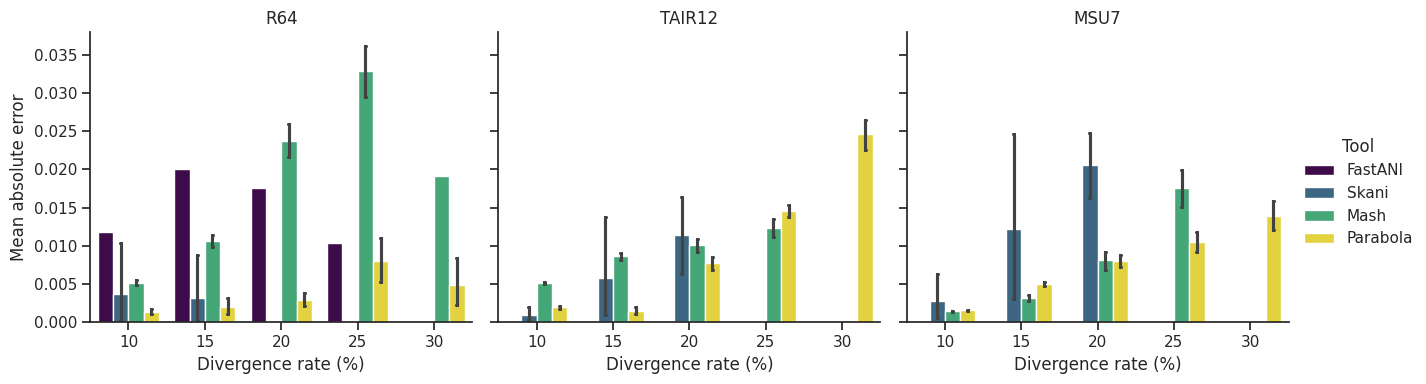

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Parabola-SupplTable1.csv")
df = df[df['Mode'] == 'SNP_ONLY']

palette_raw = {
    'fastani': '#440154',
    'skani': '#31688e',
    'mash': '#35b779',
    'parabola': '#fde725',
}

custom_palette = {
    'FastANI': palette_raw['fastani'],
    'Skani': palette_raw['skani'],
    'Mash': palette_raw['mash'],
    'Parabola': palette_raw['parabola']
}

err_cols = ['ERR_d=0.100', 'ERR_d=0.150', 'ERR_d=0.200', 'ERR_d=0.250', 'ERR_d=0.300']
keep_cols = ['Genome', 'Tool'] + err_cols
df_sub = df[keep_cols]

df_melted = df_sub.melt(id_vars=['Genome', 'Tool'],
                        value_vars=err_cols,
                        var_name='Mutation Rate_orig',
                        value_name='Mean absolute error')

map_dict = {
    'ERR_d=0.100': '10',
    'ERR_d=0.150': '15',
    'ERR_d=0.200': '20',
    'ERR_d=0.250': '25',
    'ERR_d=0.300': '30'
}
df_melted['Divergence rate (%)'] = df_melted['Mutation Rate_orig'].map(map_dict)

sns.set_theme(style="ticks")

g = sns.catplot(
    data=df_melted,
    x='Divergence rate (%)',
    y='Mean absolute error',
    hue='Tool',
    col='Genome',
    kind='bar',
    hue_order=['FastANI', 'Skani', 'Mash', 'Parabola'],
    col_order=['R64', 'TAIR12', 'MSU7'],
    palette=custom_palette,
    capsize=0.05,
    height=4,
    aspect=1.1
)

g.set_titles("{col_name}")
plt.savefig("ext1.svg")
plt.show()

# Extended data figure 2, Supplementary data figure 1

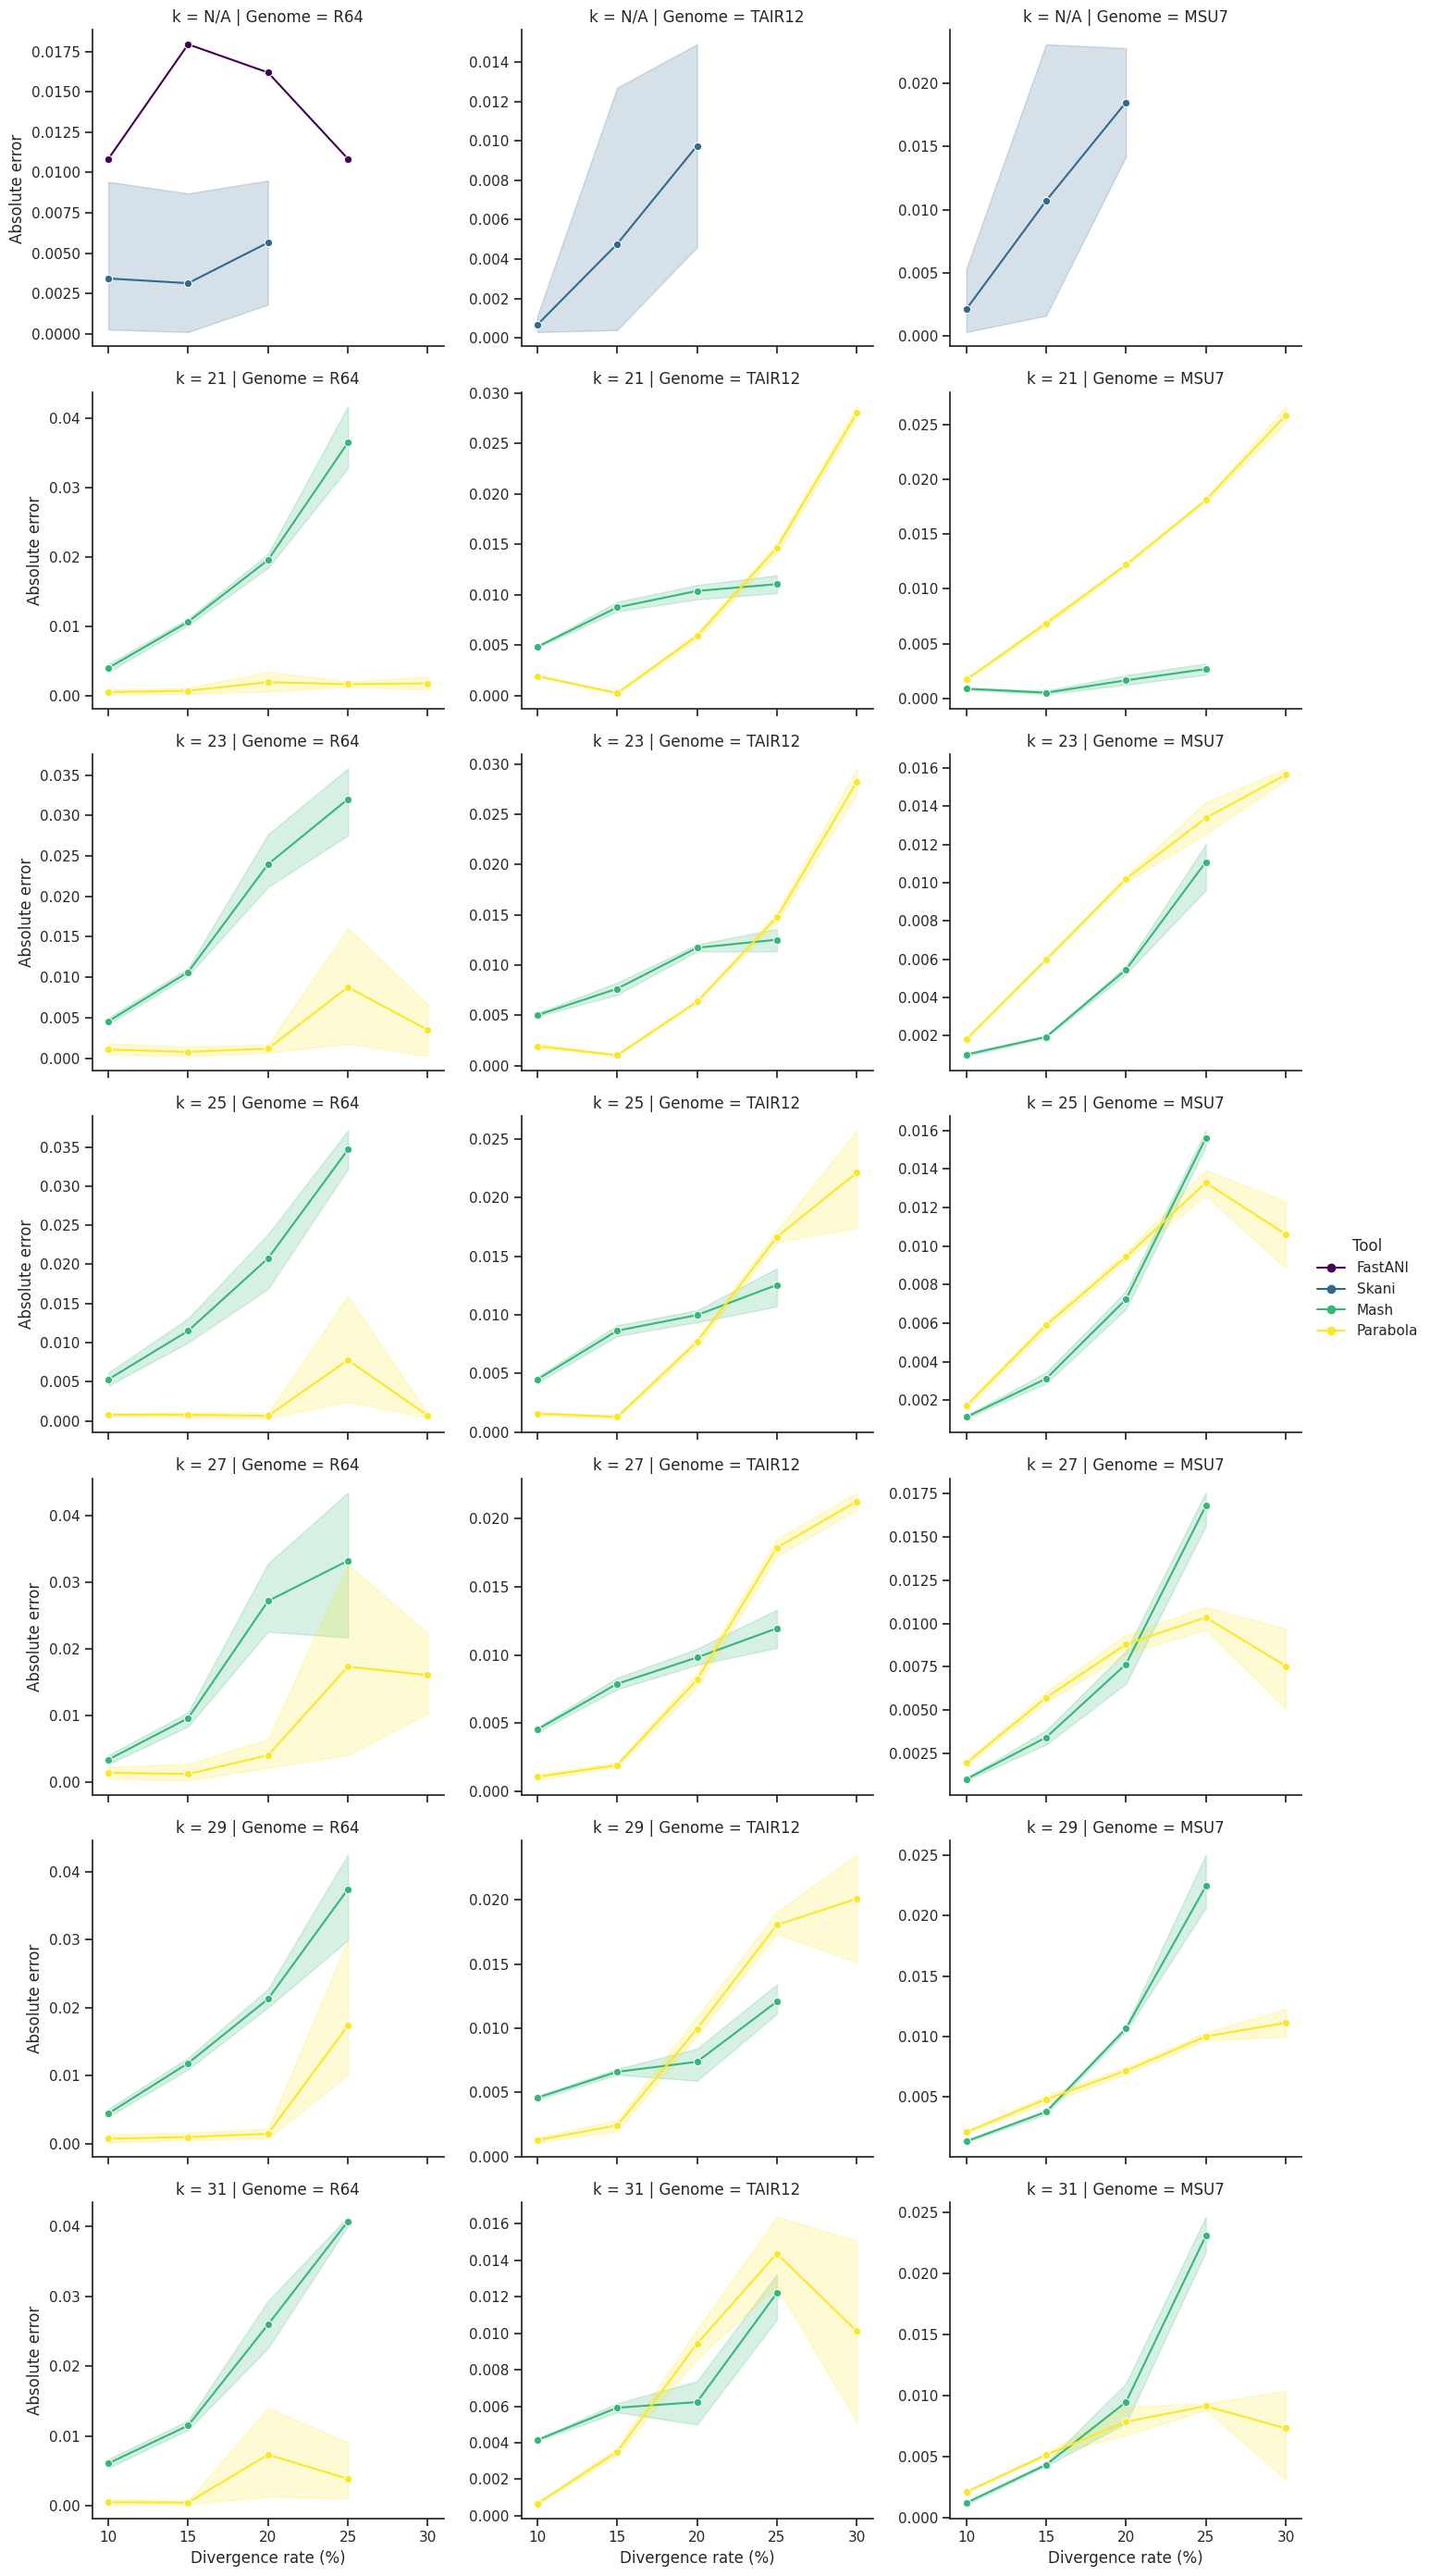

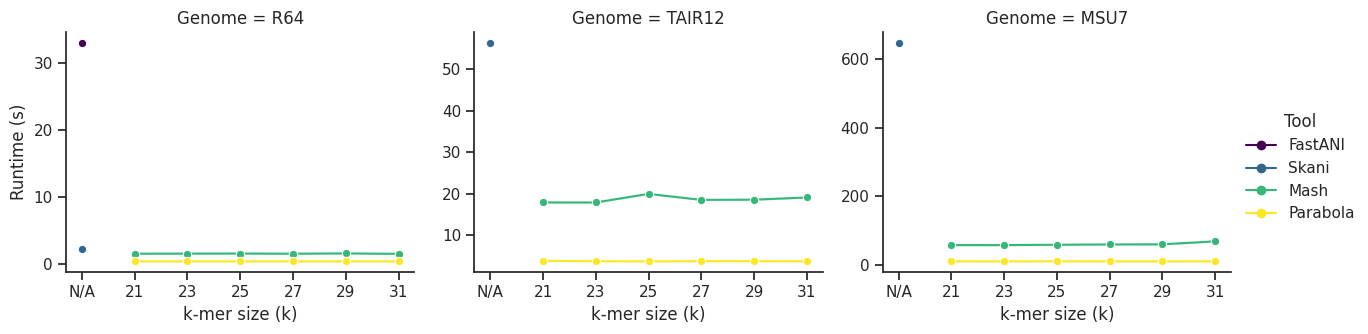

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Load data
df = pd.read_csv('Parabola-SupplTable1.csv')
df = df[df['Mode'] == 'SNP_INDEL']

df['Tool'] = df['Tool'].fillna('Unknown').astype(str)

df['k'] = df['k'].fillna('N/A')
if 'C_rate' in df.columns:
    df['C_rate'] = df['C_rate'].fillna('N/A')

palette_raw = {
    'fastani': '#440154',
    'skani': '#31688e',
    'mash': '#35b779',
    'parabola': '#fde725'
}
custom_palette = {str(t): palette_raw.get(str(t).lower(), '#808080') for t in df['Tool'].unique()}

err_cols = [c for c in df.columns if 'ERR_d=' in c]
df_err_long = df.melt(id_vars=['Tool', 'k', 'Genome', 'C_rate'],
                      value_vars=err_cols,
                      var_name='d_col',
                      value_name='Err')
df_err_long['d'] = df_err_long['d_col'].apply(lambda x: int(float(re.search(r'[\d.]+', x.split('=')[-1]).group()) * 100))
tool_order = ['FastANI', 'Skani', 'Mash', 'Parabola']

# ==========================================
# Graph: k-mer vs Error across all d
# ==========================================

g_err = sns.relplot(
    data=df_err_long,
    x='d', y='Err', hue='Tool',
    row='k', col='Genome',
    kind='line', marker='o', palette=custom_palette, height=4, aspect=1.2,
    facet_kws={'sharey': False}, hue_order=tool_order
)
g_err.set_axis_labels("Divergence rate (%)", "Absolute error")
plt.savefig("supplfig1.svg", bbox_inches='tight', dpi=330)

# ==========================================
# Graph: k-mer vs Time (keeping existing logic)
# ==========================================

df['k'] = df['k'].astype(str)

g_time = sns.relplot(
    data=df, x='k', y='Time_N=8', hue='Tool', col='Genome', col_wrap=3,
    kind='line', marker='o', palette=custom_palette, height=3.5, aspect=1.2,
    facet_kws={'sharey': False},
    hue_order=tool_order
)
g_time.set_axis_labels("k-mer size (k)", "Runtime (s)")
plt.savefig("ext2.svg", bbox_inches='tight', dpi=330)

plt.show()
plt.close()

# Extended data figure 3

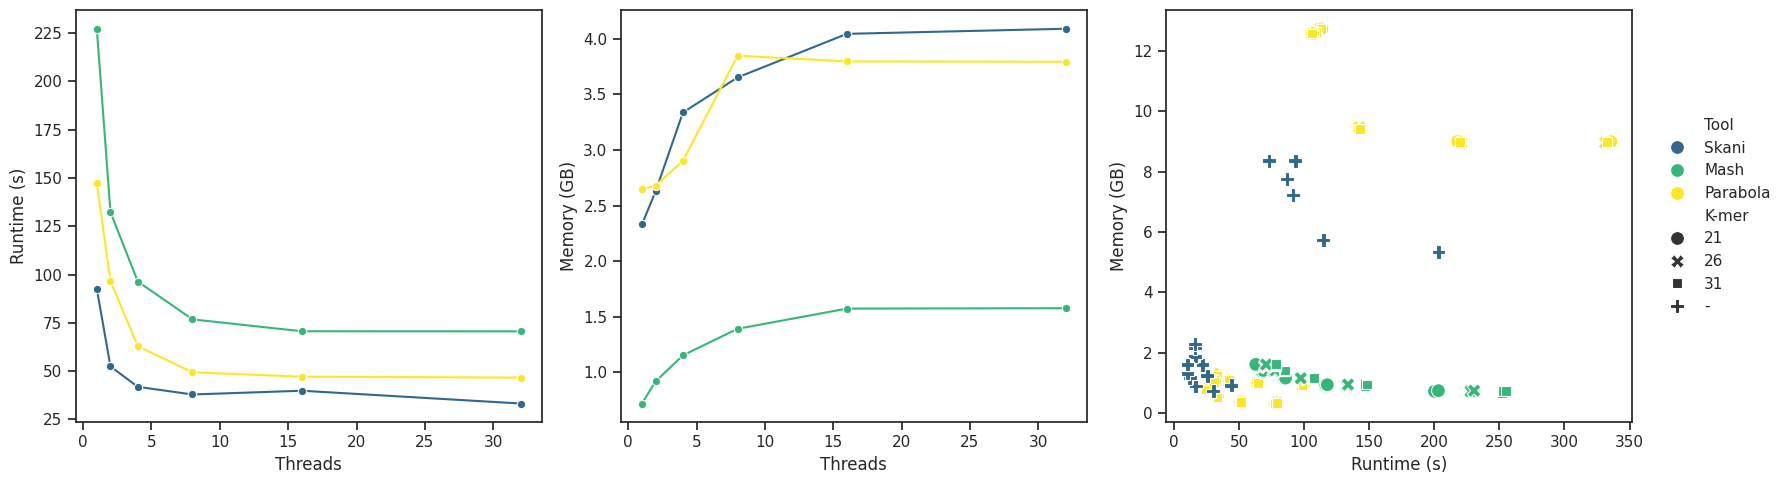

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Parabola-SupplTable2.csv')

df['memory_GB'] = df['Memory'] / (1024 * 1024)

palette_raw = {
    'skani': '#31688e',
    'mash': '#35b779',
    'parabola': '#fde725'
}
custom_palette = {t: palette_raw.get(t.lower(), '#808080') for t in df['Tool'].unique()}

tool_order = ['Skani', 'Mash', 'Parabola']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=df, x='Threads', y='Runtime', hue='Tool', marker='o', errorbar=None,
             ax=axes[0], palette=custom_palette, legend=False, hue_order=tool_order)
axes[0].set_ylabel('Runtime (s)', fontsize=12)
axes[0].set_xlabel('Threads', fontsize=12)

sns.lineplot(data=df, x='Threads', y='memory_GB', hue='Tool', marker='o', errorbar=None,
             ax=axes[1], palette=custom_palette, legend=False, hue_order=tool_order)
axes[1].set_ylabel('Memory (GB)', fontsize=12)
axes[1].set_xlabel('Threads', fontsize=12)

sns.scatterplot(data=df, x='Runtime', y='memory_GB', hue='Tool', style='K-mer',
                s=100, ax=axes[2], palette=custom_palette, hue_order=tool_order)
axes[2].set_xlabel('Runtime (s)', fontsize=12)
axes[2].set_ylabel('Memory (GB)', fontsize=12)

axes[2].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), borderaxespad=0., frameon=False)

plt.tight_layout()

plt.savefig('memory_analysis.svg', bbox_inches='tight')
plt.show()
plt.close()

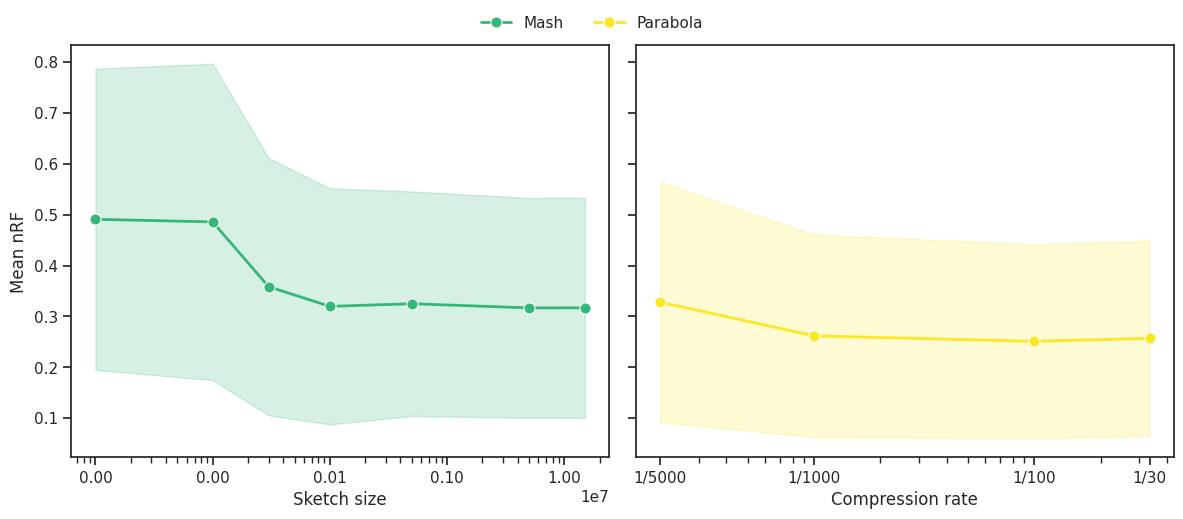

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Parabola-SupplTable3.csv')
colors = {'parabola': '#fde725', 'mash': '#35b779'}

df['Tool'] = df['Tool'].str.lower()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
plt.rcParams.update({'font.size': 12})

ax1 = axes[1]
df_para = df[df['Tool'] == 'parabola'].dropna(subset=['Scale']).copy()
df_para['ReverseScale'] = 1 / df_para['Scale']

sns.lineplot(data=df_para, x='ReverseScale', y='nRF', color=colors['parabola'],
             marker='o', linewidth=2, markersize=8, ax=ax1, errorbar='sd',
             label='Parabola')

ax1.set_xscale('log')
ticks = sorted(df_para['ReverseScale'].unique())
tick_labels = [f"1/{int(round(1/t))}" for t in ticks]
ax1.set_xticks(ticks, labels=tick_labels)
ax1.set_xlabel('Compression rate')
ax1.set_ylabel('Mean nRF')

ax2 = axes[0]
df_mash = df[df['Tool'] == 'mash'].dropna(subset=['Sketch'])

sns.lineplot(data=df_mash, x='Sketch', y='nRF', color=colors['mash'],
             marker='o', linewidth=2, markersize=8, ax=ax2, errorbar='sd',
             label='Mash')

ax2.set_xticks(sorted(df_mash['Sketch'].unique()))
ax2.set_xscale('log')
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xlabel('Sketch size')
ax2.tick_params(axis='y', labelleft=True)
ax2.set_ylabel('Mean nRF')
if ax1.get_legend() is not None: ax1.get_legend().remove()
if ax2.get_legend() is not None: ax2.get_legend().remove()

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('compression_nRF.svg', bbox_inches='tight')

plt.show()
plt.close()